# **Eksperimen 01 — Random Forest Classifier**

In [14]:
# CONFIG - File Path & Run
from datetime import datetime

labeled_data_path = "../../data/labeled/labeled_data_manual_sampling.csv"
experiment_name   = "01_random_forest"
run_id            = datetime.now().strftime("%Y%m%d_%H%M")
model_output_dir  = f"../../models/{experiment_name}/{run_id}/"

print(f"Experiment : {experiment_name}")
print(f"Run ID     : {run_id}")
print(f"Output dir : {model_output_dir}")

Experiment : 01_random_forest
Run ID     : 20260524_1724
Output dir : ../../models/01_random_forest/20260524_1724/


## **Load Data & Preprocessing**

In [15]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score,
    confusion_matrix, classification_report
)

In [16]:
# CONFIG - Preprocessing (mirror dari 02_preprocessing.ipynb)
SEED      = 42
test_size = 0.2

# Update setelah melihat hasil 01_eda.ipynb
features_to_drop = []

all_feature_columns = [
    "B2", "B3", "B4", "B8", "B11", "B12",
    "NDVI", "EVI", "SAVI", "NBR",
    "ETH_CanopyHeight",
    "Elevation", "Slope", "Aspect"
]
target_column = "Class"
id_columns    = ["longitude", "latitude"]

In [17]:
labeled_dataframe      = pd.read_csv(labeled_data_path)
active_feature_columns = [f for f in all_feature_columns if f not in features_to_drop]

feature_matrix = labeled_dataframe[active_feature_columns]
target_labels  = labeled_dataframe[target_column]

(
    train_feature_matrix, test_feature_matrix,
    train_labels, test_labels
) = train_test_split(
    feature_matrix, target_labels,
    test_size=test_size,
    random_state=SEED,
    stratify=target_labels
)

print(f"Train: {train_feature_matrix.shape[0]} samples | Test: {test_feature_matrix.shape[0]} samples")
print(f"Features used: {len(active_feature_columns)}")

Train: 165 samples | Test: 42 samples
Features used: 14


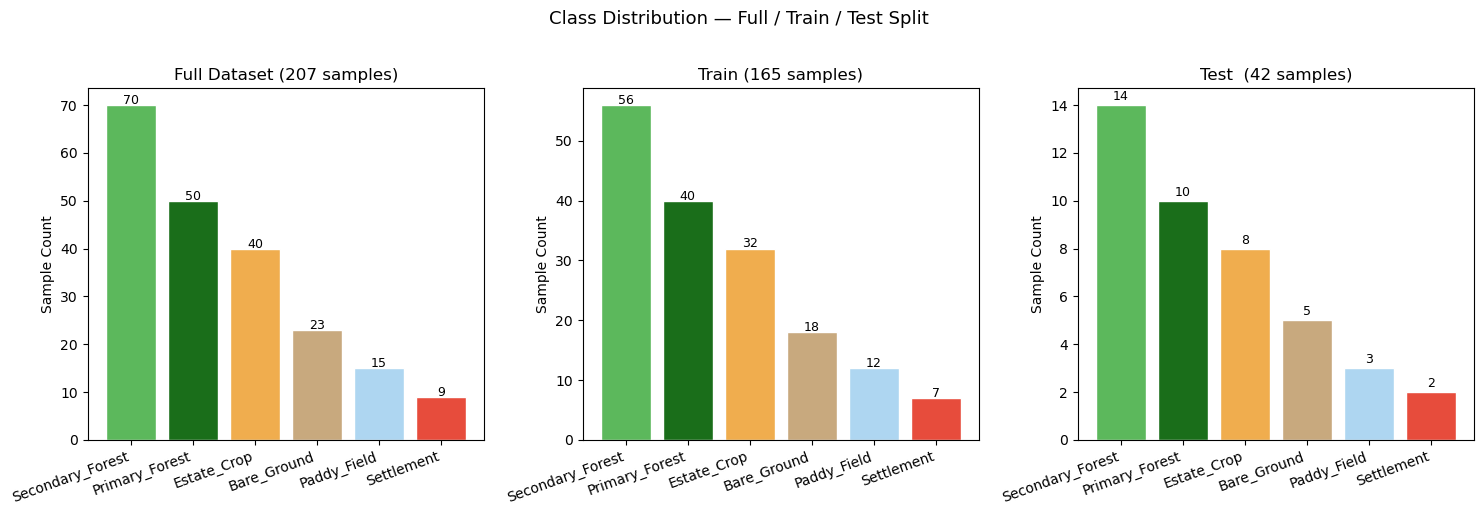

In [18]:
lulc_class_colors = {
    "Primary_Forest"   : "#1a6e1a",
    "Secondary_Forest" : "#5cb85c",
    "Estate_Crop"      : "#f0ad4e",
    "Paddy_Field"      : "#aed6f1",
    "Settlement"       : "#e74c3c",
    "Bare_Ground"      : "#c8a97e",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, (label_series, title) in zip(axes, [
    (target_labels,  f"Full Dataset ({len(target_labels)} samples)"),
    (train_labels,   f"Train ({len(train_labels)} samples)"),
    (test_labels,    f"Test  ({len(test_labels)} samples)"),
]):
    counts     = label_series.value_counts()
    bar_colors = [lulc_class_colors.get(cls, "#999") for cls in counts.index]
    ax.bar(counts.index, counts.values, color=bar_colors, edgecolor="white")
    ax.set_title(title)
    ax.set_ylabel("Sample Count")
    ax.set_xlabel("")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.2, str(v), ha="center", fontsize=9)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

plt.suptitle("Class Distribution — Full / Train / Test Split", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
# **Hyperparameter Tuning**

In [19]:
# CONFIG - Hyperparameter
param_grid = {
    "n_estimators"     : [100, 200, 300, 400],
    "max_depth"        : [None, 10, 20, 30, 40, 50],
    "min_samples_split": [2, 5, 10],
    "max_features"     : ["sqrt", "log2"],
    "class_weight"     : ["balanced"],
}

cross_val_folds = 5
scoring_metric  = "f1_macro"

In [20]:
stratified_kfold = StratifiedKFold(
    n_splits=cross_val_folds,
    shuffle=True,
    random_state=SEED
)

base_rf_model = RandomForestClassifier(random_state=SEED)

random_search = RandomizedSearchCV(
    estimator=base_rf_model,
    param_distributions=param_grid,
    n_iter=50,
    cv=stratified_kfold,
    scoring=scoring_metric,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
    random_state=SEED
)

random_search.fit(train_feature_matrix, train_labels)

print("\nBest parameters:")
print(random_search.best_params_)
print(f"\nBest CV {scoring_metric}: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END class_weight=balanced, max_depth=40, max_features=log2, min_samples_split=10, n_estimators=200; total time=   0.2s
[CV] END class_weight=balanced, max_depth=40, max_features=log2, min_samples_split=10, n_estimators=200; total time=   0.2s
[CV] END class_weight=balanced, max_depth=40, max_features=log2, min_samples_split=10, n_estimators=200; total time=   0.2s
[CV] END class_weight=balanced, max_depth=40, max_features=log2, min_samples_split=10, n_estimators=200; total time=   0.2s
[CV] END class_weight=balanced, max_depth=40, max_features=log2, min_samples_split=10, n_estimators=200; total time=   0.2s
[CV] END class_weight=balanced, max_depth=30, max_features=sqrt, min_samples_split=10, n_estimators=300; total time=   0.3s
[CV] END class_weight=balanced, max_depth=None, max_features=log2, min_samples_split=5, n_estimators=400; total time=   0.3s
[CV] END class_weight=balanced, max_depth=None, max_features=log2, mi

In [21]:
cv_results_dataframe = pd.DataFrame(random_search.cv_results_)
cv_top_results = cv_results_dataframe.sort_values("mean_test_score", ascending=False).head(10)

display_columns = [
    "rank_test_score", "mean_test_score", "std_test_score",
    "param_n_estimators", "param_max_depth",
    "param_min_samples_split", "param_max_features"
]
print("Top 10 CV results:")
cv_top_results[display_columns].to_string(index=False)

Top 10 CV results:


' rank_test_score  mean_test_score  std_test_score  param_n_estimators param_max_depth  param_min_samples_split param_max_features\n               1         0.659010        0.082527                 100            None                        5               log2\n               1         0.659010        0.082527                 100              50                        5               sqrt\n               1         0.659010        0.082527                 100              20                        5               log2\n               1         0.659010        0.082527                 100              40                        5               sqrt\n               1         0.659010        0.082527                 100            None                        5               sqrt\n               6         0.653577        0.075159                 300              10                        5               log2\n               7         0.651298        0.068518                 200             

---
# **Evaluasi Model**

In [22]:
best_rf_model    = random_search.best_estimator_
predicted_labels = best_rf_model.predict(test_feature_matrix)

overall_accuracy = accuracy_score(test_labels, predicted_labels)
kappa_score      = cohen_kappa_score(test_labels, predicted_labels)

print(f"Overall Accuracy : {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Kappa Score      : {kappa_score:.4f}")

Overall Accuracy : 0.8095 (80.95%)
Kappa Score      : 0.7500


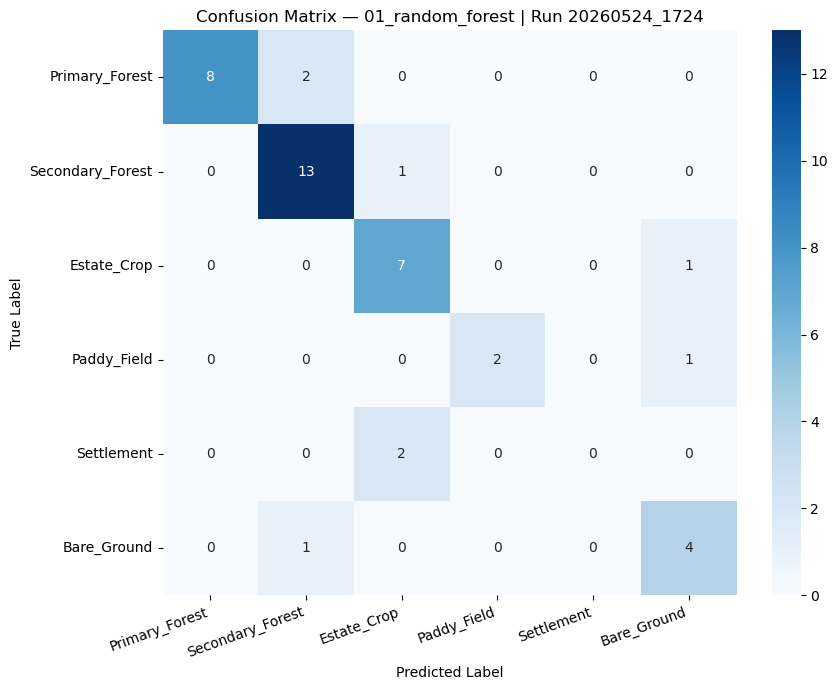

In [23]:
lulc_class_order = [
    "Primary_Forest", "Secondary_Forest", "Estate_Crop",
    "Paddy_Field", "Settlement", "Bare_Ground"
]

confusion_matrix_array = confusion_matrix(
    test_labels, predicted_labels, labels=lulc_class_order
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    confusion_matrix_array,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=lulc_class_order,
    yticklabels=lulc_class_order,
    ax=ax
)
ax.set_title(f"Confusion Matrix — {experiment_name} | Run {run_id}")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [24]:
report_text = classification_report(test_labels, predicted_labels, labels=lulc_class_order)
print("Classification Report:")
print(report_text)

Classification Report:
                  precision    recall  f1-score   support

  Primary_Forest       1.00      0.80      0.89        10
Secondary_Forest       0.81      0.93      0.87        14
     Estate_Crop       0.70      0.88      0.78         8
     Paddy_Field       1.00      0.67      0.80         3
      Settlement       0.00      0.00      0.00         2
     Bare_Ground       0.67      0.80      0.73         5

        accuracy                           0.81        42
       macro avg       0.70      0.68      0.68        42
    weighted avg       0.79      0.81      0.79        42



/Users/faqihfirmanpratama/miniforge3/envs/caps30/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/faqihfirmanpratama/miniforge3/envs/caps30/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/faqihfirmanpratama/miniforge3/envs/caps30/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


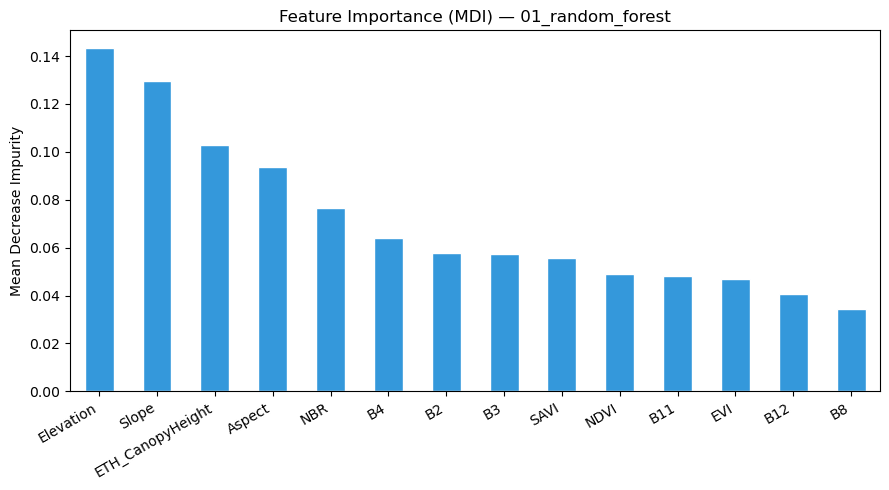

Elevation           0.143580
Slope               0.129557
ETH_CanopyHeight    0.102870
Aspect              0.093609
NBR                 0.076474
B4                  0.064232
B2                  0.057824
B3                  0.057150
SAVI                0.055505
NDVI                0.048956
B11                 0.048200
EVI                 0.046997
B12                 0.040528
B8                  0.034518


In [25]:
feature_importance_values = best_rf_model.feature_importances_
feature_importance_series = pd.Series(
    feature_importance_values, index=active_feature_columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
feature_importance_series.plot(kind="bar", ax=ax, color="#3498db", edgecolor="white")
ax.set_title(f"Feature Importance (MDI) — {experiment_name}")
ax.set_ylabel("Mean Decrease Impurity")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(feature_importance_series.to_string())

---
# **Simpan Model & Config**

In [26]:
os.makedirs(model_output_dir, exist_ok=True)

model_save_path = model_output_dir + "model.pkl"
joblib.dump(best_rf_model, model_save_path)
print(f"Model saved: {model_save_path}")

Model saved: ../../models/01_random_forest/20260524_1724/model.pkl


In [27]:
lulc_classes = sorted(target_labels.unique().tolist())

run_config = {
    "experiment_name" : experiment_name,
    "run_id"          : run_id,
    "features_used"   : active_feature_columns,
    "features_dropped": features_to_drop,
    "classes"         : lulc_classes,
    "best_params"     : random_search.best_params_,
    "cv_f1_macro"     : round(float(random_search.best_score_), 6),
    "test_accuracy"   : round(float(overall_accuracy), 6),
    "kappa_score"     : round(float(kappa_score), 6),
    "seed"            : SEED,
    "test_size"       : test_size,
    "trained_date"    : datetime.now().strftime("%Y-%m-%d %H:%M")
}

config_save_path = model_output_dir + "config.json"
with open(config_save_path, "w") as config_file:
    json.dump(run_config, config_file, indent=4)

print(f"Config saved: {config_save_path}")
print(json.dumps(run_config, indent=4))

Config saved: ../../models/01_random_forest/20260524_1724/config.json
{
    "experiment_name": "01_random_forest",
    "run_id": "20260524_1724",
    "features_used": [
        "B2",
        "B3",
        "B4",
        "B8",
        "B11",
        "B12",
        "NDVI",
        "EVI",
        "SAVI",
        "NBR",
        "ETH_CanopyHeight",
        "Elevation",
        "Slope",
        "Aspect"
    ],
    "features_dropped": [],
    "classes": [
        "Bare_Ground",
        "Estate_Crop",
        "Paddy_Field",
        "Primary_Forest",
        "Secondary_Forest",
        "Settlement"
    ],
    "best_params": {
        "n_estimators": 100,
        "min_samples_split": 5,
        "max_features": "sqrt",
        "max_depth": 40,
        "class_weight": "balanced"
    },
    "cv_f1_macro": 0.65901,
    "test_accuracy": 0.809524,
    "kappa_score": 0.75,
    "seed": 42,
    "test_size": 0.2,
    "trained_date": "2026-05-24 17:24"
}
